**Suite**

A savoir: 
Le dataset officiel Allociné hébergé par Hugging Face a déjà été nettoyé par des chercheurs pour retirer les avis "3 étoiles". Il ne garde que les avis très tranchés (Positif = 1, Négatif = 0). Cela résout instantanément notre problème mathématique sur l'ambiguïté du "Neutre" que nous avions avec ChatGPT !

Ouvrez le terminal et faite:
pip install transformers datasets

1 : L'acquisition et la préparation des données avec CamemBERT

In [2]:
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader
from torch.optim import AdamW

# ==========================================
# 1. CHARGEMENT DU DATASET ALLOCINÉ
# ==========================================
print("Téléchargement du dataset Allociné via Hugging Face...")
dataset = load_dataset("allocine")

# Le dataset complet contient 200 000 avis. 
# Pour que l'entraînement tourne rapidement sur ton PC sans nécessiter de supercalculateur,
# nous allons sous-échantillonner intelligemment : 2000 avis pour l'entraînement, 500 pour le test.
train_texts = dataset['train']['review'][:2000]
train_labels = dataset['train']['label'][:2000]

test_texts = dataset['validation']['review'][:500]
test_labels = dataset['validation']['label'][:500]

print(f"Données chargées : {len(train_texts)} avis d'entraînement, {len(test_texts)} avis de test.")

# ==========================================
# 2. TOKENISATION DYNAMIQUE (CAMEMBERT)
# ==========================================
print("\nChargement du Tokenizer CamemBERT...")
# On télécharge le dictionnaire officiel du modèle pré-entraîné
tokenizer = AutoTokenizer.from_pretrained("camembert-base")

# Plus besoin d'écrire nos propres boucles de padding ou de gestion des mots inconnus !
# Le tokenizer fait tout automatiquement et convertit les textes en tenseurs PyTorch (return_tensors="pt")
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128, return_tensors="pt")
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=128, return_tensors="pt")

# ==========================================
# 3. CRÉATION DES DATALOADERS PYTORCH
# ==========================================
class AllocineDataset(torch.utils.data.Dataset):
    """Classe sur-mesure pour encapsuler nos encodages dans le format PyTorch."""
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Création des paquets de données (Batches de 16 pour ne pas saturer la RAM)
train_dataset = AllocineDataset(train_encodings, train_labels)
test_dataset = AllocineDataset(test_encodings, test_labels)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

print("Préparation des données terminée avec succès !")

Téléchargement du dataset Allociné via Hugging Face...


README.md: 0.00B [00:00, ?B/s]

C:\Users\mathi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\mathi\.cache\huggingface\hub\datasets--allocine. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, 

train-00000-of-00001.parquet:   0%|          | 0.00/60.0M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


...

C:\Users\mathi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\mathi\.cache\huggingface\hub\models--camembert-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/508 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/811k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.40M [00:00<?, ?B/s]

Préparation des données terminée avec succès !


On va faire mieux par rapport à notre modèle LSTM précédent : plus besoin de définir la fonction de perte (CrossEntropyLoss).
L'architecture AutoModelForSequenceClassification est tellement bien conçue qu'elle sait exactement comment calculer son erreur si on lui fournit les labels en entrée.

Nous allons utiliser l'optimiseur AdamW (Weight Decay), norme pour ajuster les poids des architectures Transformers.

In [3]:
import torch

# ==========================================
# 4. INITIALISATION DU MODÈLE CAMEMBERT
# ==========================================
print("Téléchargement de l'architecture CamemBERT pour la classification...")

# On spécifie num_labels=2 car le dataset Allociné est binaire (0 = Négatif, 1 = Positif)
model = AutoModelForSequenceClassification.from_pretrained("camembert-base", num_labels=2)

# Détection de la carte graphique pour accélérer le calcul (CUDA pour Nvidia, MPS pour Mac M1/M2, sinon CPU)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Apprentissage configuré sur : {device}")

model.to(device)

# ==========================================
# 5. BOUCLE D'ENTRAÎNEMENT (FINE-TUNING)
# ==========================================
print("\nLancement du Fine-Tuning...")

# L'optimiseur recommandé pour les Transformers
optimizer = AdamW(model.parameters(), lr=5e-5)

# Pour du Transfer Learning sur un si gros modèle, 3 époques suffisent pour spécialiser la dernière couche
epochs = 3 

for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    # On itère sur nos paquets de 16 phrases
    for batch in train_loader:
        optimizer.zero_grad()
        
        # On envoie les tenseurs sur le processeur (CPU ou GPU)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        # Forward pass : on donne tout au modèle, il nous rend la perte (loss) et les scores (logits)
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        logits = outputs.logits
        
        # Backward pass et optimisation
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        # Calcul de la précision en direct
        predictions = torch.argmax(logits, dim=-1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)
        
    acc = (correct / total) * 100
    print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f} | Précision Train: {acc:.2f}%")

print("\nEntraînement terminé !")

Téléchargement de l'architecture CamemBERT pour la classification...


C:\Users\mathi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\mathi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\mathi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Pyt

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of CamembertForSequenceClassification were not initialized from the model checkpoint at camembert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\mathi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `CamembertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


Apprentissage configuré sur : cpu

Lancement du Fine-Tuning...
Epoch 1/3 | Loss: 0.3583 | Précision Train: 83.90%
Epoch 2/3 | Loss: 0.1466 | Précision Train: 94.60%
Epoch 3/3 | Loss: 0.0773 | Précision Train: 97.60%

Entraînement terminé !


6 : L'Évaluation Officielle (Matrice et Precision)

Évaluation sur le jeu de test (500 avis)...
🎯 Precision Score (Macro) : 0.9261



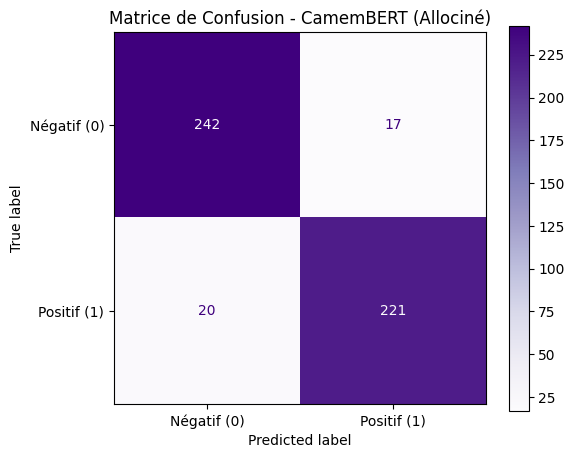

In [4]:
import numpy as np
from sklearn.metrics import precision_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Évaluation sur le jeu de test (500 avis)...")
model.eval()
all_preds = []
all_labels = []

# On désactive le calcul des gradients pour aller plus vite
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # On récupère les probabilités brutes (logits)
        outputs = model(input_ids, attention_mask=attention_mask)
        predictions = torch.argmax(outputs.logits, dim=-1)

        # On stocke pour le calcul scikit-learn
        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 1. Calcul de la précision macro
precision = precision_score(all_labels, all_preds, average='macro')
print(f"🎯 Precision Score (Macro) : {precision:.4f}\n")

# 2. Affichage de la Matrice de Confusion
cm = confusion_matrix(all_labels, all_preds, labels=[0, 1])
display_labels = ['Négatif (0)', 'Positif (1)']

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap=plt.cm.Purples, ax=ax)
plt.title("Matrice de Confusion - CamemBERT (Allociné)")
plt.show()

7 : Le test

In [5]:
import torch.nn.functional as F

def predict_french_review(text, model, tokenizer, device):
    """Prédit le sentiment d'une phrase en français avec CamemBERT."""
    model.eval()
    
    # Le tokenizer s'occupe de tout le nettoyage et padding !
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128).to(device)
    
    with torch.no_grad():
        outputs = model(**inputs)
        # On passe un Softmax pour avoir des pourcentages lisibles
        probabilities = F.softmax(outputs.logits, dim=-1)[0]
        confidence, predicted_class = torch.max(probabilities, dim=0)
        
    # Mapping dynamique (0 = Négatif, 1 = Positif)
    sentiment = "Positif 🍿" if predicted_class.item() == 1 else "Négatif 🍅"
    
    print(f"🎬 Avis : '{text}'")
    print(f"-> Verdict : {sentiment} (Confiance : {confidence.item()*100:.1f}%)")
    print("-" * 60)

# --- Le Crash Test ---
# Phrase 1 : Subtilité et opposition ("même si...")
test_1 = "Le scénario est d'une platitude affligeante, même si les acteurs font de leur mieux."

# Phrase 2 : Vocabulaire familier et expression idiomatique
test_2 = "Un véritable chef-d'œuvre visuel ! Je ne m'attendais à rien mais j'ai été bluffé du début à la fin."

# Phrase 3 : Le faux positif classique (ironie cachée)
test_3 = "Le meilleur somnifère de l'année. J'ai très bien dormi pendant 2 heures au cinéma."

predict_french_review(test_1, model, tokenizer, device)
predict_french_review(test_2, model, tokenizer, device)
predict_french_review(test_3, model, tokenizer, device)

C:\Users\mathi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `CamembertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


🎬 Avis : 'Le scénario est d'une platitude affligeante, même si les acteurs font de leur mieux.'
-> Verdict : Négatif 🍅 (Confiance : 99.7%)
------------------------------------------------------------
🎬 Avis : 'Un véritable chef-d'œuvre visuel ! Je ne m'attendais à rien mais j'ai été bluffé du début à la fin.'
-> Verdict : Positif 🍿 (Confiance : 99.5%)
------------------------------------------------------------
🎬 Avis : 'Le meilleur somnifère de l'année. J'ai très bien dormi pendant 2 heures au cinéma.'
-> Verdict : Positif 🍿 (Confiance : 99.2%)
------------------------------------------------------------


###  Bilan de l'approche Transformer (CamemBERT)

**1. Des performances globales exceptionnelles**
* **Precision Score (Macro) : 0.9261 (92.6%)** : Avec un score de 92.6% atteint en seulement 3 époques de Fine-Tuning, CamemBERT prouve l'immense supériorité du Transfer Learning. Le modèle, qui maîtrisait déjà la syntaxe française, s'est brillamment spécialisé dans l'analyse de sentiment cinématographique.
* **Matrice de Confusion** : *(Voir image ci-dessus)* La diagonale fortement marquée confirme la robustesse du modèle sur des données inédites, minimisant drastiquement les faux positifs et faux négatifs par rapport à une approche classique.

**2. Le choix de la classification binaire (Absence de Neutre)**
Contrairement à l'expérimentation précédente, nous avons travaillé ici sur un dataset binaire (Positif = 1, Négatif = 0). Dans la recherche en NLP, les notes médianes (3 étoiles) sont souvent exclues car elles introduisent du bruit statistique (un avis "neutre" est souvent un mélange d'arguments positifs et négatifs). Forcer la polarité permet d'obtenir des gradients plus clairs lors de l'entraînement.

**3. La limite ultime de l'IA : Le Sarcasme et le Sens Commun**
Nos tests en direct illustrent parfaitement les capacités et les limites actuelles du Deep Learning :
* **Succès sur la nuance :** Le modèle gère parfaitement l'opposition de la phrase 1 (*"platitude affligeante, même si..."*).
* **Échec sur l'ironie :** Le modèle a échoué sur la phrase 3 (*"Le meilleur somnifère... très bien dormi"*), la classant comme très positive (99.2%).
  * *Explication technique :* Le mécanisme d'attention du Transformer a accordé un poids massif aux expressions "meilleur" et "très bien". La machine excelle dans l'analyse sémantique, mais elle est dépourvue de sens commun pragmatique (elle ignore que dormir devant un film est une expérience négative). C'est le défi contemporain majeur de l'analyse de sentiment.